In [1]:
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import pandas as pd
import time
import requests
import json
import os
from dotenv import load_dotenv
import io
from shapely.geometry import shape
from shapely.wkt import loads
import pytz

In [2]:
load_dotenv()
api_key = os.getenv("API_KEY_V2")

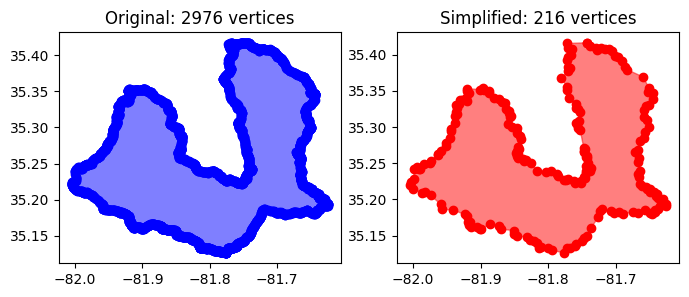

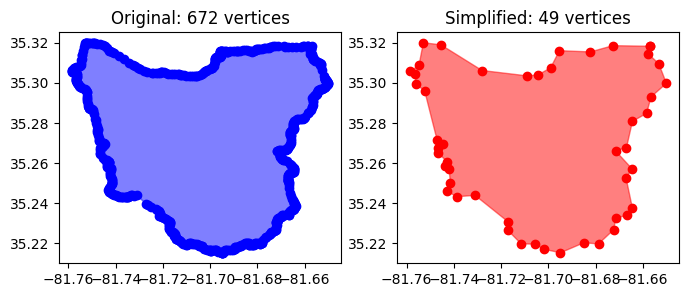

Number of reaches in HUC 0305010505: 115
Number of reaches in HUC 030501050505: 10
Bounding box for HUC 0305010505: -82.0042452632381,35.1263579406994,-81.6244580206719,35.4173656246555
Bounding box for HUC 030501050505: -81.7584896224679,35.2152677152613,-81.6499919134945,35.3199846565011


In [3]:
from shapely.plotting import plot_polygon
from matplotlib import pyplot as plt
def get_reach_list_and_geometry_for_huc(huc):
    with open(f'data/huc_{huc}_geometries.geojson') as f:
        data = json.load(f)
        reach_id_list = [feature['id'] for feature in data['features']]
    with open(f'data/huc_geometry_data.json') as f:
        huc_polygon_data = json.loads(f.read())
        for i in range(len(huc_polygon_data)):
            if huc_polygon_data[i]['huc'] == huc:
                wkt_string = huc_polygon_data[i]['geometry']
                geometry = shape(loads(wkt_string))
                minx, miny, maxx, maxy = geometry.bounds
                bbox_string = f"{minx},{miny},{maxx},{maxy}"
                geometry_simplified = geometry.simplify(0.001, preserve_topology=True)
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
                plot_polygon(geometry, ax=ax1, add_points=True, color='blue', alpha=0.5)
                ax1.set_title(f'Original: {len(geometry.exterior.coords)} vertices')
                plot_polygon(geometry_simplified, ax=ax2, add_points=True, color='red', alpha=0.5)
                ax2.set_title(f'Simplified: {len(geometry_simplified.exterior.coords)} vertices')
                plt.show()
                wkt_string = geometry_simplified.wkt
                break
    return reach_id_list, wkt_string, bbox_string

huc_0305010505_reach_id_list, huc_0305010505_wkt_str, huc_0305010505_bbox_string = get_reach_list_and_geometry_for_huc("0305010505")
huc_030501050505_reach_id_list, huc_030501050505_wkt_str, huc_030501050505_bbox_string = get_reach_list_and_geometry_for_huc("030501050505")
print(f"Number of reaches in HUC 0305010505: {len(huc_0305010505_reach_id_list)}")
print(f"Number of reaches in HUC 030501050505: {len(huc_030501050505_reach_id_list)}")
print(f"Bounding box for HUC 0305010505: {huc_0305010505_bbox_string}")
print(f"Bounding box for HUC 030501050505: {huc_030501050505_bbox_string}")

In [4]:
reach_mapper_dict = {
    "HUC-0305010505": ','.join(map(str, huc_0305010505_reach_id_list)),
    "HUC-030501050505": ','.join(map(str, huc_030501050505_reach_id_list)),
    "REACH-12034579": '12034579',
}

In [5]:
reach_mapper_dict["HUC-0305010505"]

'12035527,12035387,12034663,12034723,12034759,12034711,12035545,12034443,12034627,12034481,12035405,12034877,12035547,12034679,12035389,12035815,12034397,12034701,12035541,12034719,166756451,12034735,12034673,12034453,12034795,12034527,12034793,12035513,12035805,12034779,12035777,12035523,12035515,12034797,12034403,12034451,12034751,12035947,12034697,12034473,12035803,12034801,12035833,12035517,12035565,12034577,12035531,12034541,12034507,12035553,12035407,12034893,12035779,12035379,12035393,25776238,12034699,12035557,12034579,12034727,12034503,12034773,12034665,12034635,12034513,12034819,12034767,12035509,12034707,12035381,12034741,12035537,12034815,166756450,12035525,12034887,12035561,12034539,12034501,12035543,12035529,12035519,12034743,12034341,12034563,12035533,12034471,12035395,12034713,12034709,12034683,12034731,12034547,12034545,12034485,12034499,12034775,12035783,12035949,12035539,12034813,12035511,12034561,12035809,12035559,12034737,12034401,12035521,12035555,12035535,1203445

In [6]:
geometry_mapper_dict = {
    "HUC-0305010505": huc_0305010505_wkt_str,
    "HUC-030501050505": huc_030501050505_wkt_str,
    "Point near Reach": "POINT (-81.6760383109927 35.3173543595158)"
    }

In [7]:
bbox_mapper_dict = {
    "HUC-0305010505": huc_0305010505_bbox_string,
    "HUC-030501050505": huc_030501050505_bbox_string,
    }
bbox_mapper_dict

{'HUC-0305010505': '-82.0042452632381,35.1263579406994,-81.6244580206719,35.4173656246555',
 'HUC-030501050505': '-81.7584896224679,35.2152677152613,-81.6499919134945,35.3199846565011'}

In [8]:
huc_mapper_dict = {
    "HUC-03050105": "03050105",
    "HUC-030501050505": "030501050505",}
huc_mapper_dict

{'HUC-03050105': '03050105', 'HUC-030501050505': '030501050505'}

In [9]:
API_ROOT_URL = 'https://nwm-api-v2-9f6idmxh.uc.gateway.dev'
FORECASTS = f'{API_ROOT_URL}/forecasts'
ANALYSES_ASSIM = f'{API_ROOT_URL}/analyses-assim'
RETROSPECTIVES = f'{API_ROOT_URL}/retrospectives'
PERCENTILE_FLOWS = f'{API_ROOT_URL}/percentile-flows'
FLOW_METRICS = f'{API_ROOT_URL}/flow-metrics'
RETURN_PERIODS = f'{API_ROOT_URL}/return-periods'
GEOMETRIES = f'{API_ROOT_URL}/geometries'

In [11]:
def get_nwm_data(endpoint, params):
    start = time.perf_counter()
    r = requests.get(url=endpoint, params=params, 
                     headers={
                         'x-api-key': api_key
                         })
    if r.status_code == 200:
        if 'output_format' in params.keys():
            if params['output_format'] == 'csv':
                if params['metadata']:
                    df = pd.read_csv(io.StringIO(r.text), comment='#')
                else:
                    df = pd.read_csv(io.StringIO(r.text))
                print("Data dimension:", df.shape)
                end = time.perf_counter()
                elaspse = end - start
                mst_timezone = pytz.timezone('America/Denver')
                utc_now = datetime.now(pytz.utc)
                mst_now = utc_now.astimezone(mst_timezone)
                print("Job timestamp (MST):", mst_now.strftime("%Y-%m-%d %H:%M:%S"))
                return elaspse
            elif params['output_format'] in ['json', 'geojson']:
                json_data = json.loads(r.text)
                if params['metadata'] and params['output_format'] == "json":
                    print("Data dimension:", len(json_data['data']))
                elif not params['metadata'] and params['output_format'] == "json":
                    print("Data dimension:", len(json_data))
                elif params['output_format'] == "geojson":
                    print("Data dimension:", len(json_data['features']))
                end = time.perf_counter()
                elaspse = end - start
                mst_timezone = pytz.timezone('America/Denver')
                utc_now = datetime.now(pytz.utc)
                mst_now = utc_now.astimezone(mst_timezone)
                print("Job timestamp (MST):", mst_now.strftime("%Y-%m-%d %H:%M:%S"))
                return elaspse
            else:
                end = time.perf_counter()
                print("Other formats will not be parsed here.")
                mst_timezone = pytz.timezone('America/Denver')
                utc_now = datetime.now(pytz.utc)
                mst_now = utc_now.astimezone(mst_timezone)
                print("Job timestamp (MST):", mst_now.strftime("%Y-%m-%d %H:%M:%S"))
                elaspse = end - start
                return elaspse
        else:
            json_data = json.loads(r.text)
            end = time.perf_counter()
            elaspse = end - start
            return elaspse
    else:
        print("HTTP Error:", r.text)

In [12]:
def retro_case_run(case, end_date, ordered, metadata=False, output_format="csv"):
    with open(f'results/nwmapiv2/retro_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = RETROSPECTIVES,
                params = {
                    'start_time': "2022-01-01T00:00:00",
                    'end_time': end_date,
                    'reach_id': reach_id_list_str,
                    'output_format': output_format,
                    'ordered': ordered,
                    'metadata': metadata
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [13]:
# Retro Case 1: streamflow + 1 week
retro_case_run("case01", "2022-01-08T00:00:00", ordered=False, metadata=False)

Data dimension: (19435, 4)
Job timestamp (MST): 2026-04-07 22:13:51
{'label': 'HUC-0305010505', 'elapsed_time_sec': 5.832636333012488}
________________________________________
Data dimension: (1690, 4)
Job timestamp (MST): 2026-04-07 22:13:53
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.599325666000368}
________________________________________
Data dimension: (169, 4)
Job timestamp (MST): 2026-04-07 22:13:54
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.2837938749871682}
________________________________________


In [14]:
# Retro Case 2: streamflow + 1 month
retro_case_run("case02", "2022-02-01T00:00:00", ordered=False, metadata=False)

Data dimension: (85675, 4)
Job timestamp (MST): 2026-04-07 22:14:06
{'label': 'HUC-0305010505', 'elapsed_time_sec': 9.580900375003694}
________________________________________
Data dimension: (7450, 4)
Job timestamp (MST): 2026-04-07 22:14:08
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.9411540830042213}
________________________________________
Data dimension: (745, 4)
Job timestamp (MST): 2026-04-07 22:14:10
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.4397603340039495}
________________________________________


In [15]:
# Retro Case 3: streamflow + 1 week + ordered
retro_case_run("case03", "2022-01-08T00:00:00", ordered=True, metadata=False)

Data dimension: (19435, 4)
Job timestamp (MST): 2026-04-07 22:14:18
{'label': 'HUC-0305010505', 'elapsed_time_sec': 5.423052666999865}
________________________________________
Data dimension: (1690, 4)
Job timestamp (MST): 2026-04-07 22:14:19
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.5197602910047863}
________________________________________
Data dimension: (169, 4)
Job timestamp (MST): 2026-04-07 22:14:20
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.1471300419943873}
________________________________________


In [16]:
# Retro Case 4: streamflow + 1 week + metadata
retro_case_run("case04", "2022-01-08T00:00:00", ordered=False, metadata=True)

Data dimension: (19435, 4)
Job timestamp (MST): 2026-04-07 22:14:28
{'label': 'HUC-0305010505', 'elapsed_time_sec': 5.191079624986742}
________________________________________
Data dimension: (1690, 4)
Job timestamp (MST): 2026-04-07 22:14:29
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.5266185000073165}
________________________________________
Data dimension: (169, 4)
Job timestamp (MST): 2026-04-07 22:14:31
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.242302041995572}
________________________________________


In [17]:
# Retro Case 5: streamflow + 1 week + json output
retro_case_run("case05", "2022-01-08T00:00:00", ordered=False, metadata=False, output_format="json")

Data dimension: 19435
Job timestamp (MST): 2026-04-07 22:14:52
{'label': 'HUC-0305010505', 'elapsed_time_sec': 5.1208627079904545}
________________________________________
Data dimension: 1690
Job timestamp (MST): 2026-04-07 22:14:53
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.4951984170184005}
________________________________________
Data dimension: 169
Job timestamp (MST): 2026-04-07 22:14:54
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.1138899170036893}
________________________________________


In [18]:
# Retro Case 6: streamflow + 1 week + geojson output
retro_case_run("case06", "2022-01-08T00:00:00", ordered=False, metadata=False, output_format="geojson")

Data dimension: 19435
Job timestamp (MST): 2026-04-07 22:15:32
{'label': 'HUC-0305010505', 'elapsed_time_sec': 18.966739791998407}
________________________________________
Data dimension: 1690
Job timestamp (MST): 2026-04-07 22:15:36
{'label': 'HUC-030501050505', 'elapsed_time_sec': 3.946861667005578}
________________________________________
Data dimension: 169
Job timestamp (MST): 2026-04-07 22:15:39
{'label': 'REACH-12034579', 'elapsed_time_sec': 2.7465994170052}
________________________________________


In [19]:
# Retro Case 7: streamflow + 1 week + geopackage output
retro_case_run("case07", "2022-01-08T00:00:00", ordered=False, metadata=False, output_format="geopackage")

Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:16:20
{'label': 'HUC-0305010505', 'elapsed_time_sec': 10.784015332988929}
________________________________________
Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:16:23
{'label': 'HUC-030501050505', 'elapsed_time_sec': 3.3895887919934466}
________________________________________
Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:16:25
{'label': 'REACH-12034579', 'elapsed_time_sec': 2.0510550829931162}
________________________________________


In [20]:
def analysis_case_run(case, end_date):
    with open(f'results/nwmapiv2/analysis_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = ANALYSES_ASSIM,
                params = {
                    'start_time': "2024-01-01T00:00:00",
                    'end_time': end_date,
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [21]:
# Analysis Case 1: 1 week
analysis_case_run("case_01", "2024-01-08T00:00:00")

Data dimension: (19435, 4)
Job timestamp (MST): 2026-04-07 22:17:05
{'label': 'HUC-0305010505', 'elapsed_time_sec': 15.939458583976375}
________________________________________
Data dimension: (1690, 4)
Job timestamp (MST): 2026-04-07 22:17:12
{'label': 'HUC-030501050505', 'elapsed_time_sec': 6.974733041977743}
________________________________________
Data dimension: (169, 4)
Job timestamp (MST): 2026-04-07 22:17:21
{'label': 'REACH-12034579', 'elapsed_time_sec': 8.979444083000999}
________________________________________


In [22]:
# Analysis Case 2: 1 month
analysis_case_run("case_02", "2024-02-01T00:00:00")

Data dimension: (85675, 4)
Job timestamp (MST): 2026-04-07 22:18:02
{'label': 'HUC-0305010505', 'elapsed_time_sec': 11.069623624993255}
________________________________________
Data dimension: (7450, 4)
Job timestamp (MST): 2026-04-07 22:18:11
{'label': 'HUC-030501050505', 'elapsed_time_sec': 8.938149208988762}
________________________________________
Data dimension: (745, 4)
Job timestamp (MST): 2026-04-07 22:18:16
{'label': 'REACH-12034579', 'elapsed_time_sec': 5.785503833991243}
________________________________________


In [23]:
def srf_case_run(case):
    with open(f'results/nwmapiv2/short_range_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = FORECASTS,
                params = {
                    'forecast_type': 'short_range',
                    'reference_time': "2024-01-01T00:00:00",
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")          

In [24]:
# Short-range Case 1
srf_case_run("case_01")

Data dimension: (2070, 6)
Job timestamp (MST): 2026-04-07 22:19:10
{'label': 'HUC-0305010505', 'elapsed_time_sec': 3.984136499988381}
________________________________________
Data dimension: (180, 6)
Job timestamp (MST): 2026-04-07 22:19:12
{'label': 'HUC-030501050505', 'elapsed_time_sec': 2.042176999995718}
________________________________________
Data dimension: (18, 6)
Job timestamp (MST): 2026-04-07 22:19:15
{'label': 'REACH-12034579', 'elapsed_time_sec': 2.1474030840035994}
________________________________________


In [25]:
def mrf_case_run(case, ensemble):
    with open(f'results/nwmapiv2/medium_range_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = FORECASTS,
                params = {
                    'forecast_type': 'medium_range',
                    'reference_time': "2024-01-01T00:00:00",
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'ensemble': ensemble,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [26]:
# Medium-range Case 1: Single ensemble member (member 3)
mrf_case_run("case_01", ensemble="3")

Data dimension: (23460, 6)
Job timestamp (MST): 2026-04-07 22:19:39
{'label': 'HUC-0305010505', 'elapsed_time_sec': 15.266128457995364}
________________________________________
Data dimension: (2040, 6)
Job timestamp (MST): 2026-04-07 22:19:47
{'label': 'HUC-030501050505', 'elapsed_time_sec': 7.5377448329818435}
________________________________________
Data dimension: (204, 6)
Job timestamp (MST): 2026-04-07 22:19:57
{'label': 'REACH-12034579', 'elapsed_time_sec': 9.916838417004328}
________________________________________


In [27]:
# Medium-range Case 2: Average of all ensemble members
mrf_case_run("case_02", ensemble=None)

Data dimension: (27600, 6)
Job timestamp (MST): 2026-04-07 22:20:10
{'label': 'HUC-0305010505', 'elapsed_time_sec': 9.755682332994184}
________________________________________
Data dimension: (2400, 6)
Job timestamp (MST): 2026-04-07 22:20:19
{'label': 'HUC-030501050505', 'elapsed_time_sec': 8.625404708000133}
________________________________________
Data dimension: (240, 6)
Job timestamp (MST): 2026-04-07 22:20:25
{'label': 'REACH-12034579', 'elapsed_time_sec': 6.511844458000269}
________________________________________


In [28]:
def lrf_case_run(case, ensemble):
    with open(f'results/nwmapiv2/long_range_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = FORECASTS,
                params = {
                    'forecast_type': 'long_range',
                    'reference_time': "2024-01-01T00:00:00",
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'ensemble': ensemble,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [29]:
# LRF Case 1: Single ensemble member (member 0)
lrf_case_run("case_01", ensemble="0")

Data dimension: (13800, 6)
Job timestamp (MST): 2026-04-07 22:20:41
{'label': 'HUC-0305010505', 'elapsed_time_sec': 8.214779583999189}
________________________________________
Data dimension: (1200, 6)
Job timestamp (MST): 2026-04-07 22:20:45
{'label': 'HUC-030501050505', 'elapsed_time_sec': 4.075183666020166}
________________________________________
Data dimension: (120, 6)
Job timestamp (MST): 2026-04-07 22:20:49
{'label': 'REACH-12034579', 'elapsed_time_sec': 3.701944458996877}
________________________________________


In [30]:
# LRF Case 2: Average of all ensemble members
lrf_case_run("case_02", ensemble=None)

Data dimension: (13800, 6)
Job timestamp (MST): 2026-04-07 22:21:01
{'label': 'HUC-0305010505', 'elapsed_time_sec': 6.084501708013704}
________________________________________
Data dimension: (1200, 6)
Job timestamp (MST): 2026-04-07 22:21:05
{'label': 'HUC-030501050505', 'elapsed_time_sec': 4.087020208011381}
________________________________________
Data dimension: (120, 6)
Job timestamp (MST): 2026-04-07 22:21:08
{'label': 'REACH-12034579', 'elapsed_time_sec': 3.234908374986844}
________________________________________


In [31]:
def return_period_case_run(case, return_periods=None):
    with open(f'results/nwmapiv2/return_period_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = RETURN_PERIODS,
                params = {
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': 'csv',
                    'return_periods': return_periods
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [32]:
# return period case: all return periods
return_period_case_run("case_01")

Data dimension: (115, 7)
Job timestamp (MST): 2026-04-07 22:21:25
{'label': 'HUC-0305010505', 'elapsed_time_sec': 3.0328203749959357}
________________________________________
Data dimension: (10, 7)
Job timestamp (MST): 2026-04-07 22:21:27
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.8646390409849118}
________________________________________
Data dimension: (1, 7)
Job timestamp (MST): 2026-04-07 22:21:28
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.4885565839940682}
________________________________________


In [33]:
# return period case: selected return periods
return_period_case_run("case_02", return_periods="10,50,100")

Data dimension: (115, 4)
Job timestamp (MST): 2026-04-07 22:21:48
{'label': 'HUC-0305010505', 'elapsed_time_sec': 3.1719723340065684}
________________________________________
Data dimension: (10, 4)
Job timestamp (MST): 2026-04-07 22:21:50
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.431322915974306}
________________________________________
Data dimension: (1, 4)
Job timestamp (MST): 2026-04-07 22:21:51
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.3867656249785796}
________________________________________


In [34]:
def geometry_case_run(case):
    with open(f'results/nwmapiv2/geometry_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = GEOMETRIES,
                params = {
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [35]:
# Case 1
geometry_case_run("case_01")

Data dimension: (115, 4)
Job timestamp (MST): 2026-04-07 22:22:06
{'label': 'HUC-0305010505', 'elapsed_time_sec': 1.9165977919765282}
________________________________________
Data dimension: (10, 4)
Job timestamp (MST): 2026-04-07 22:22:07
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.218709459004458}
________________________________________
Data dimension: (1, 4)
Job timestamp (MST): 2026-04-07 22:22:09
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.6262925839982927}
________________________________________


In [36]:
def flow_metrics_case_run(case):
    with open(f'results/nwmapiv2/flow_metrics_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = FLOW_METRICS,
                params = {
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [37]:
flow_metrics_case_run("case_01")

Data dimension: (115, 17)
Job timestamp (MST): 2026-04-07 22:22:22
{'label': 'HUC-0305010505', 'elapsed_time_sec': 2.5731459590024315}
________________________________________
Data dimension: (10, 17)
Job timestamp (MST): 2026-04-07 22:22:23
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.075498082995182}
________________________________________
Data dimension: (1, 17)
Job timestamp (MST): 2026-04-07 22:22:25
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.1337399999902118}
________________________________________


In [38]:
def percentile_flows_case_run(case, ordered, metadata=False, output_format="csv"):
    with open(f'results/nwmapiv2/percentile_flows_{case}.json', "w") as f:
        for label, reach_id_list_str in reach_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = PERCENTILE_FLOWS,
                params = {
                    'reach_id': reach_id_list_str,
                    'metadata': False,
                    'output_format': output_format,
                    'ordered': ordered,
                    'metadata': metadata
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [39]:
# Percentile Flows Case 1: unordered percentiles
percentile_flows_case_run("case_01", ordered=False, metadata=False, output_format="csv")

Data dimension: (115, 14)
Job timestamp (MST): 2026-04-07 22:22:38
{'label': 'HUC-0305010505', 'elapsed_time_sec': 1.22698741700151}
________________________________________
Data dimension: (10, 14)
Job timestamp (MST): 2026-04-07 22:22:39
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.0049965840007644}
________________________________________
Data dimension: (1, 14)
Job timestamp (MST): 2026-04-07 22:22:40
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.0629101670056116}
________________________________________


In [40]:
# Percentile Flows Case 2: ordered percentiles
percentile_flows_case_run("case_02", ordered=True, metadata=False, output_format="csv")

Data dimension: (115, 14)
Job timestamp (MST): 2026-04-07 22:22:44
{'label': 'HUC-0305010505', 'elapsed_time_sec': 1.1176868749898858}
________________________________________
Data dimension: (10, 14)
Job timestamp (MST): 2026-04-07 22:22:46
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.168795665988}
________________________________________
Data dimension: (1, 14)
Job timestamp (MST): 2026-04-07 22:22:47
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.1279687079950236}
________________________________________


In [41]:
# Percentile Flows Case 3: metadata case
percentile_flows_case_run("case_03", ordered=False, metadata=True, output_format="csv")

Data dimension: (115, 14)
Job timestamp (MST): 2026-04-07 22:22:53
{'label': 'HUC-0305010505', 'elapsed_time_sec': 1.2970670000067912}
________________________________________
Data dimension: (10, 14)
Job timestamp (MST): 2026-04-07 22:22:54
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.0730167079891544}
________________________________________
Data dimension: (1, 14)
Job timestamp (MST): 2026-04-07 22:22:55
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.0176879159989767}
________________________________________


In [42]:
# Percentile Flows Case 4: JSON output_format case
percentile_flows_case_run("case_04", ordered=False, metadata=False, output_format="json")

Data dimension: 115
Job timestamp (MST): 2026-04-07 22:23:00
{'label': 'HUC-0305010505', 'elapsed_time_sec': 0.9277776660164818}
________________________________________
Data dimension: 10
Job timestamp (MST): 2026-04-07 22:23:01
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.0417612089950126}
________________________________________
Data dimension: 1
Job timestamp (MST): 2026-04-07 22:23:02
{'label': 'REACH-12034579', 'elapsed_time_sec': 0.8802828330080956}
________________________________________


In [43]:
# Percentile Flows Case 5: GeoJSON output_format case
percentile_flows_case_run("case_05", ordered=False, metadata=False, output_format="geojson")

Data dimension: 115
Job timestamp (MST): 2026-04-07 22:23:09
{'label': 'HUC-0305010505', 'elapsed_time_sec': 2.028483333007898}
________________________________________
Data dimension: 10
Job timestamp (MST): 2026-04-07 22:23:10
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.6982353750208858}
________________________________________
Data dimension: 1
Job timestamp (MST): 2026-04-07 22:23:12
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.6533775409916416}
________________________________________


In [44]:
# Percentile Flows Case 6: Shapefile output_format case
percentile_flows_case_run("case_06", ordered=False, metadata=False, output_format="shapefile")

Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:23:17
{'label': 'HUC-0305010505', 'elapsed_time_sec': 2.3175526249979157}
________________________________________
Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:23:19
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.971366334008053}
________________________________________
Other formats will not be parsed here.
Job timestamp (MST): 2026-04-07 22:23:21
{'label': 'REACH-12034579', 'elapsed_time_sec': 1.988509457994951}
________________________________________


#### Intra-comparison

Use geom_filter

In [45]:
def geom_filter_case_run(case):
    with open(f'results/nwmapiv2/geom_filter_{case}.json', "w") as f:
        for label, geometry_geojson_str in geometry_mapper_dict.items():
            print(geometry_geojson_str)
            elapsed = get_nwm_data(
                endpoint = GEOMETRIES,
                params = {
                    'geom_filter': geometry_geojson_str,
                    'metadata': False,
                    'output_format': 'csv'
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")
        

In [46]:
# Compare small vs large geometry filter cases
geom_filter_case_run("case_01")

POLYGON ((-81.7418386979363 35.4163906321628, -81.7723868902284 35.4154414381037, -81.7704058320258 35.4096379973781, -81.7645335749831 35.4078218732603, -81.7658911374459 35.4000371872013, -81.7711167658915 35.3968508727944, -81.7723531358211 35.3928164979432, -81.7709093890252 35.3832600564092, -81.7681584464321 35.3812110560829, -81.770251763481 35.3770219915834, -81.7806247066277 35.3674436714743, -81.7714777647198 35.3555180526485, -81.7719617636082 35.35172273725, -81.7684391983417 35.3394737941853, -81.7591855701607 35.3313939209608, -81.7591021333999 35.3264268542954, -81.7548865070655 35.3247951082776, -81.7528993208361 35.3207383533331, -81.7547645050974 35.3088601070167, -81.7584931976869 35.3056978468372, -81.7566485762483 35.3045977904252, -81.7558751892599 35.2991879195253, -81.7523849370151 35.2960707262925, -81.7470916267915 35.2714752234017, -81.7446048728191 35.2694239688966, -81.7467163743699 35.2673870319307, -81.7467212596599 35.2650860939465, -81.7428363166013 35.

Use bounding_box

In [47]:
def bbox_case_run(case, lowest_stream_order = None):
    with open(f'results/nwmapiv2/bbox_{case}.json', "w") as f:
        for label, bbox_string in bbox_mapper_dict.items():
            elapsed = get_nwm_data(
                endpoint = GEOMETRIES,
                params = {
                    'bounding_box': bbox_string,
                    'metadata': False,
                    'output_format': 'csv',
                    'lowest_stream_order': lowest_stream_order
                })
            elapsed_time_dict = {
                "label": label,
                "elapsed_time_sec": elapsed
            }
            print(elapsed_time_dict)
            print("_" * 40)
            f.write(json.dumps(elapsed_time_dict) + "\n")

In [48]:
# Geom Filter Case 1:  (Small bounding box vs large bounding box)
bbox_case_run("case_01")

Data dimension: (271, 4)
Job timestamp (MST): 2026-04-07 22:23:52
{'label': 'HUC-0305010505', 'elapsed_time_sec': 1.4685125410032924}
________________________________________
Data dimension: (43, 4)
Job timestamp (MST): 2026-04-07 22:23:53
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.4267660419864114}
________________________________________


In [49]:
# Geom Filter Case 2:  Effect of lowest stream order filter on the large bounding box case
bbox_case_run("case_01", lowest_stream_order=3)

Data dimension: (74, 4)
Job timestamp (MST): 2026-04-07 22:24:07
{'label': 'HUC-0305010505', 'elapsed_time_sec': 2.7796860409725923}
________________________________________
Data dimension: (13, 4)
Job timestamp (MST): 2026-04-07 22:24:08
{'label': 'HUC-030501050505', 'elapsed_time_sec': 1.3032292909920216}
________________________________________
